In [1]:
from __future__ import print_function, division
from arch_config import *
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import time
import os
import copy
import kagglehub
import shutil

In [2]:
deep_head = nn.Sequential(
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 9),
)

# data
dataloaders, class_names, dataset_sizes, vis_loader = get_dataloaders()
train_set, val_set, test_set = dataloaders['train'], dataloaders['val'], dataloaders['test']

# Новый слой для resnet

## без заморозки

In [20]:
# model
res_mod = models.resnet18(weights='IMAGENET1K_V1')
res_mod.fc = deep_head

res_mod = res_mod.to(device)

criterion = nn.CrossEntropyLoss()
# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(res_mod.parameters(), lr=0.001, momentum=0.9)
# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [22]:
deep_raw = train_model(res_mod, criterion, optimizer_ft, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 0.9026 | Acc: 0.7451

Training complete in 74m 12s
Best val Acc: 0.745928


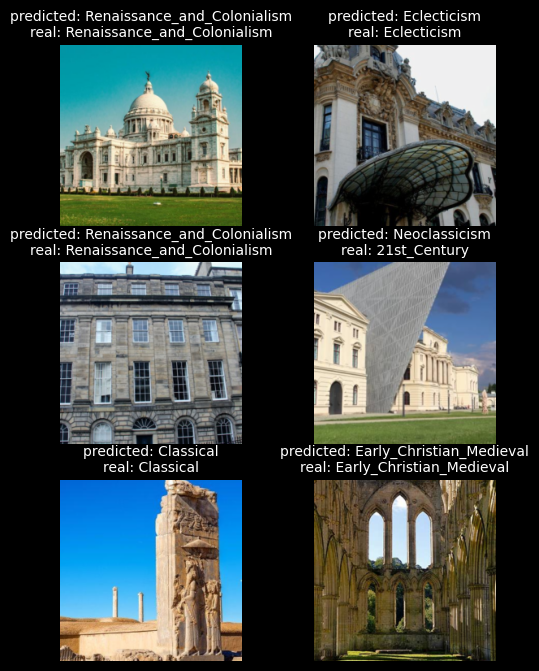

In [24]:
visualize_model(deep_raw, num_images=6, class_names=class_names, vis_loader=vis_loader)

## с заморозкой

In [3]:
res_mod_freeze = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod_freeze.named_children():
     if name == 'fc':
         print(name + ' has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

res_mod_freeze.fc = deep_head

res_mod_freeze = res_mod_freeze.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_conv = torch.optim.SGD(filter(lambda x: x.requires_grad, res_mod_freeze.parameters()), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

fc has been unfrozen.


In [4]:
deep_raw_freeze, metrics = train_model(res_mod_freeze, criterion, optimizer_conv, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.1411 | Acc: 0.6018 | Weighted Acc: 0.5560 | F1-macro: 0.6002 | Top-1 Acc: 0.6018 | Top-3 Acc: 0.8836
Epoch Time: 19.3693s

Training complete in 7m 59s
Best val Weighted Acc: 0.577008 | Best F1-score: 0.6184 | Best Top-1 Acc: 0.6189 | Best Top-3 Acc: 0.8917


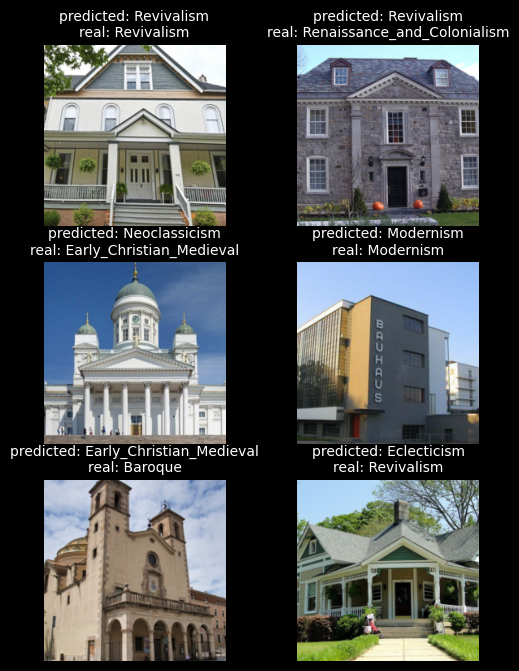

In [5]:
visualize_model(deep_raw_freeze, num_images=6, class_names=class_names, vis_loader=vis_loader)

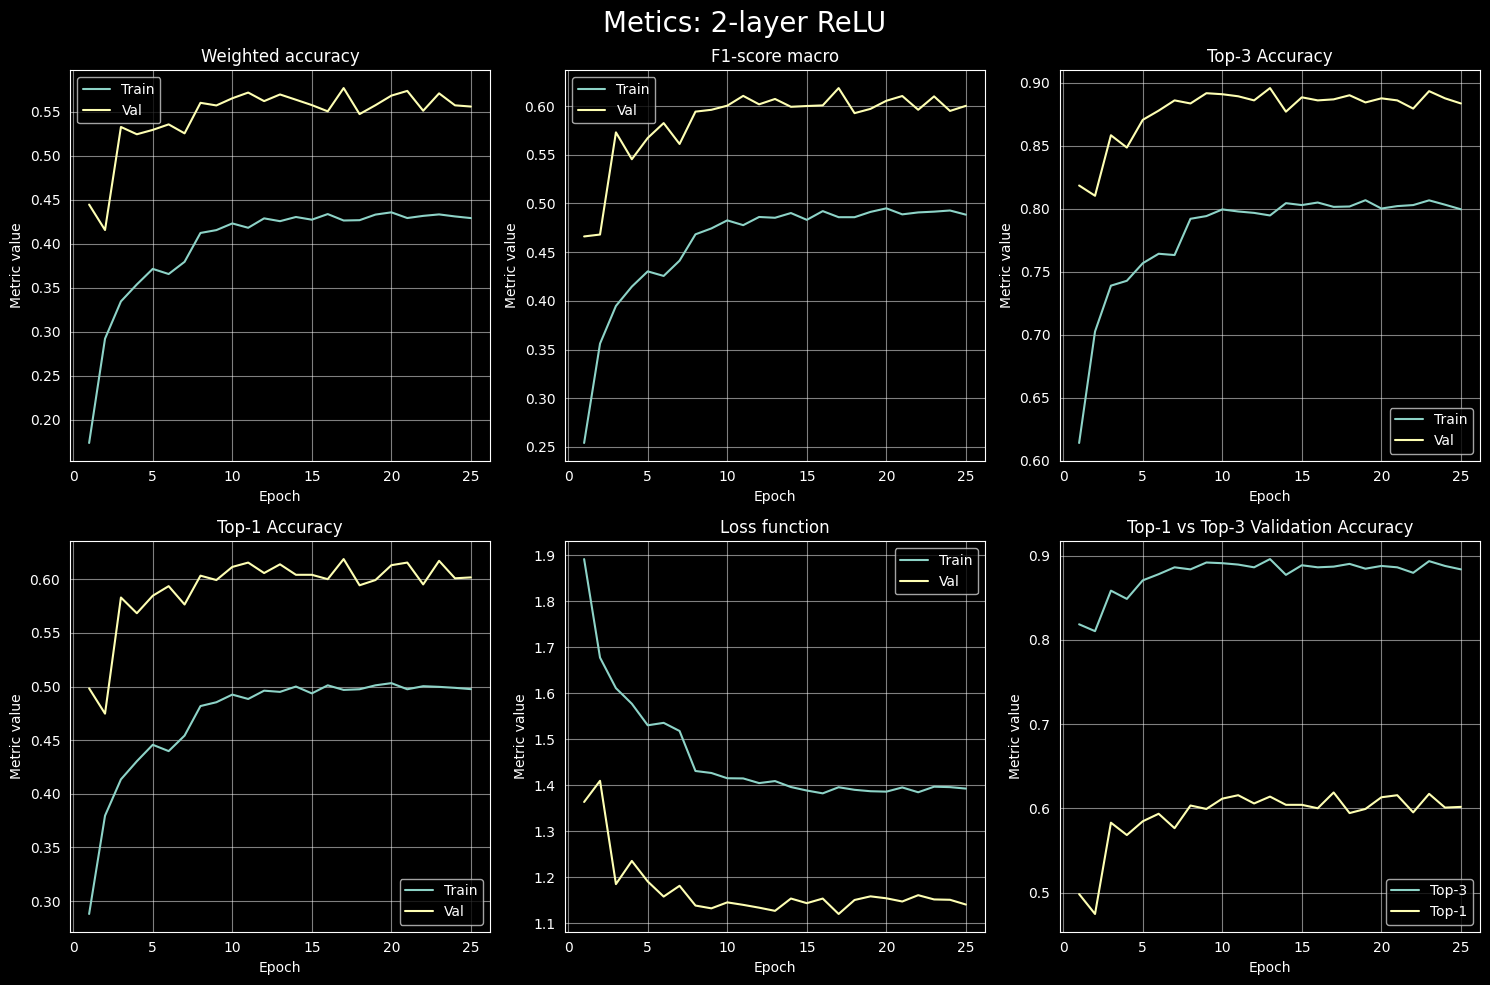

In [6]:
visualize_metrics(metrics, "Metics: 2-layer ReLU", 25)

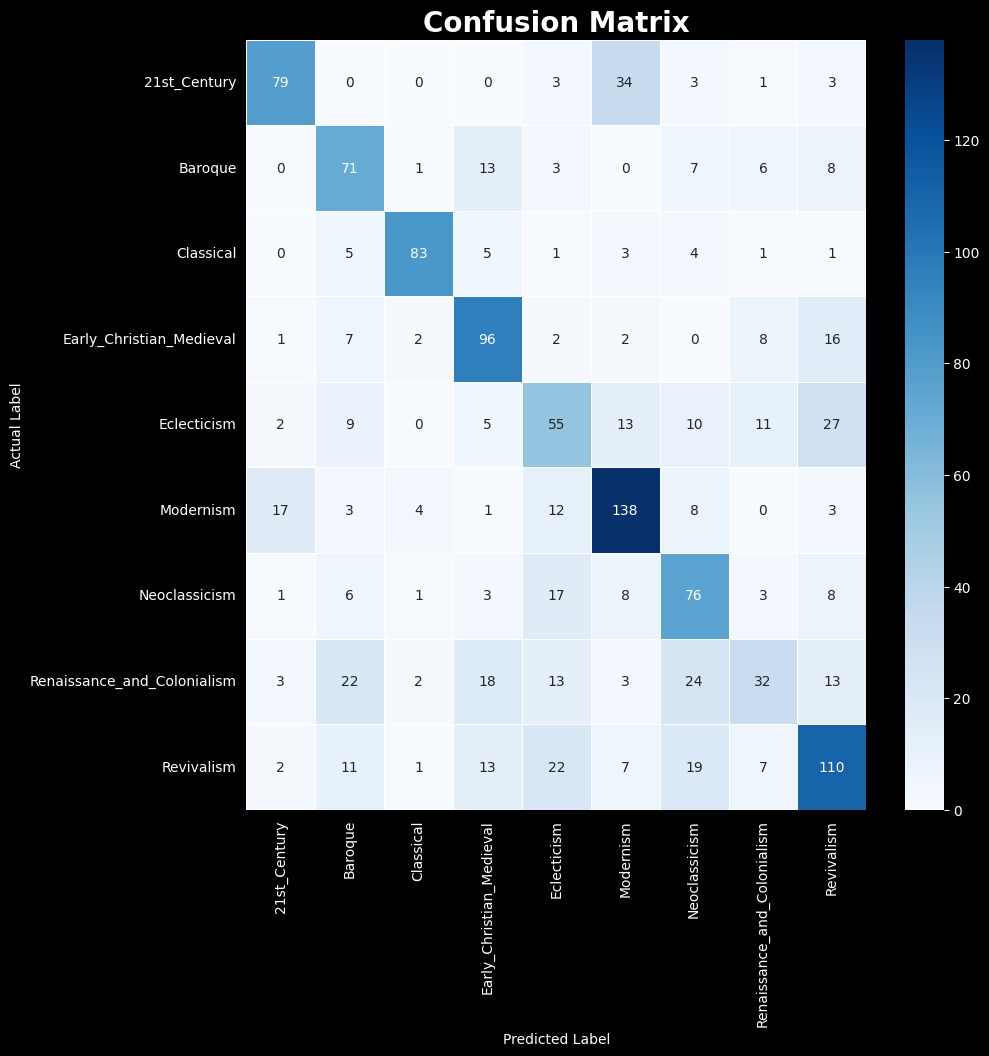

In [7]:
visualize_cm(deep_raw_freeze, class_names, test_set)

In [8]:
torch.save(deep_raw_freeze, 'deep_base.pt')

# эксперимент: GeLU

In [9]:
deep_gelu = nn.Sequential(
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.GELU(),
    nn.Linear(128, 9),
)

In [10]:
res_mod_gelu = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod_gelu.named_children():
     if name == 'fc':
         print(name + ' has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

res_mod_gelu.fc = deep_gelu

res_mod_gelu = res_mod_gelu.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_conv = torch.optim.SGD(filter(lambda x: x.requires_grad, res_mod_gelu.parameters()), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

fc has been unfrozen.


In [11]:
deep_gelu, metrics_gelu = train_model(res_mod_gelu, criterion, optimizer_conv, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.0791 | Acc: 0.6319 | Weighted Acc: 0.5869 | F1-macro: 0.6308 | Top-1 Acc: 0.6319 | Top-3 Acc: 0.9055
Epoch Time: 17.6445s

Training complete in 7m 21s
Best val Weighted Acc: 0.586901 | Best F1-score: 0.6308 | Best Top-1 Acc: 0.6319 | Best Top-3 Acc: 0.9055


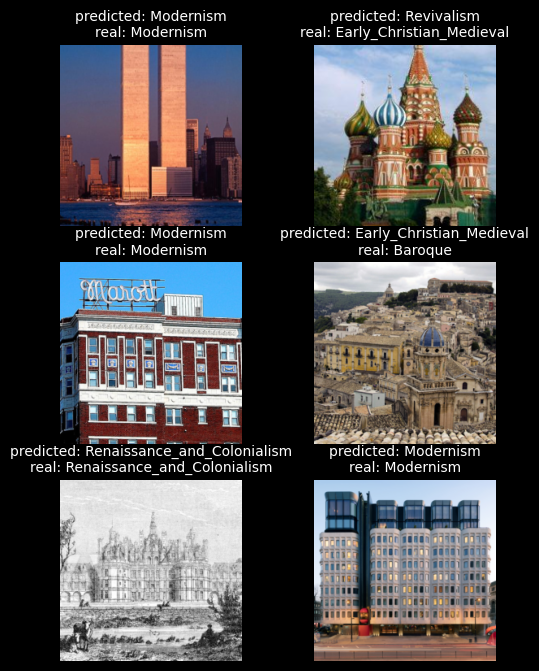

In [12]:
visualize_model(deep_gelu, num_images=6, class_names=class_names, vis_loader=vis_loader)

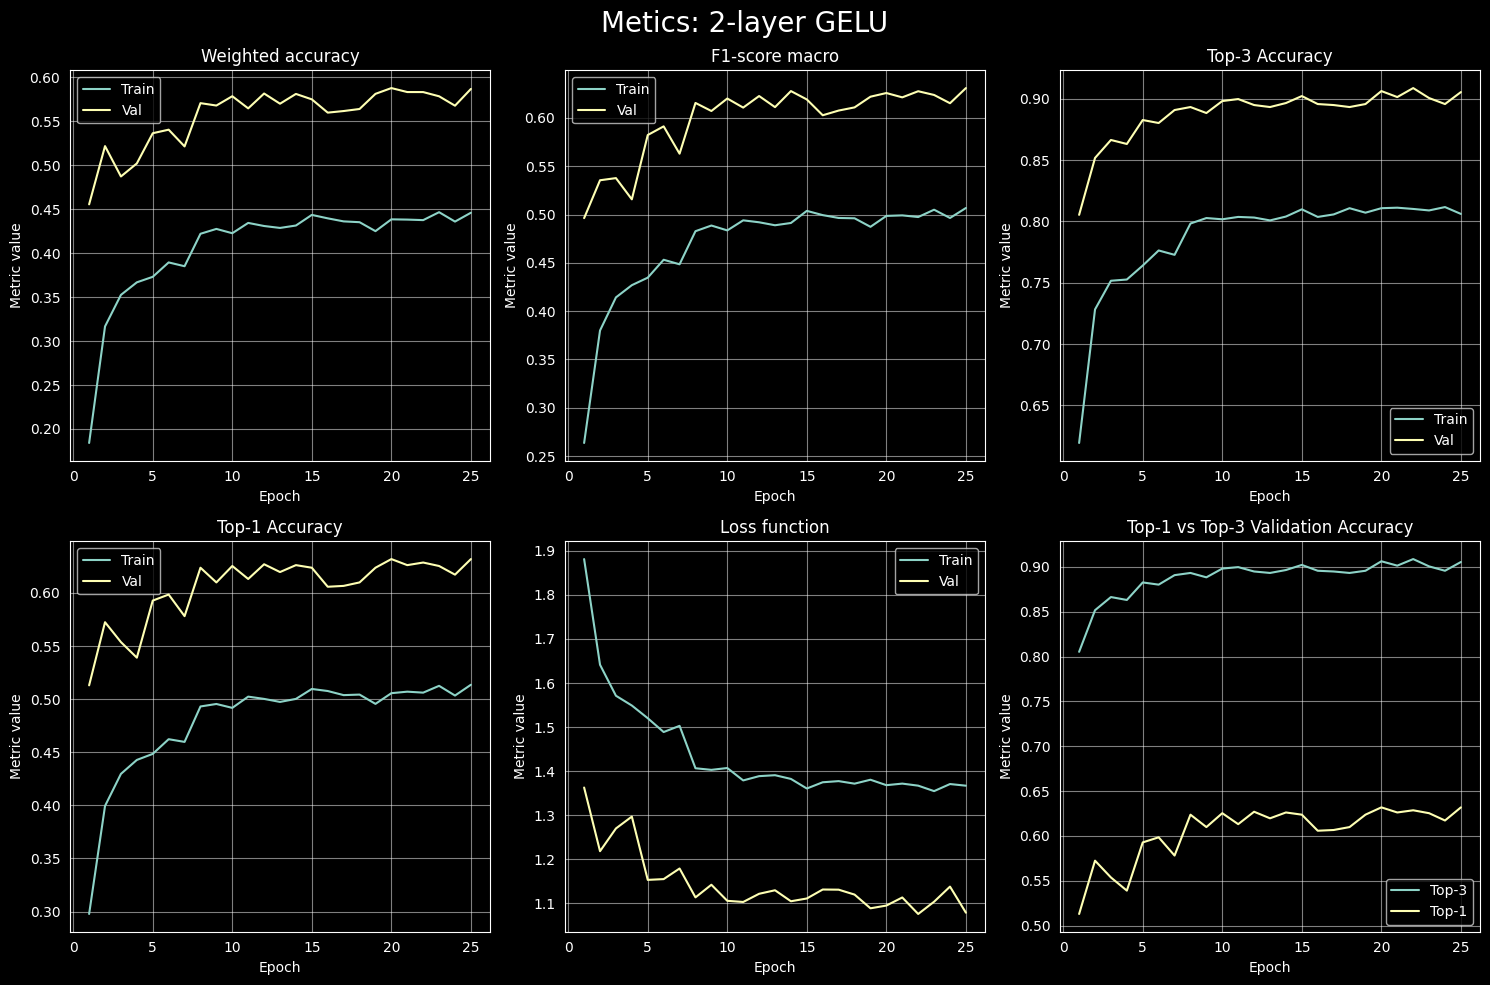

In [13]:
visualize_metrics(metrics_gelu, "Metics: 2-layer GELU", 25)

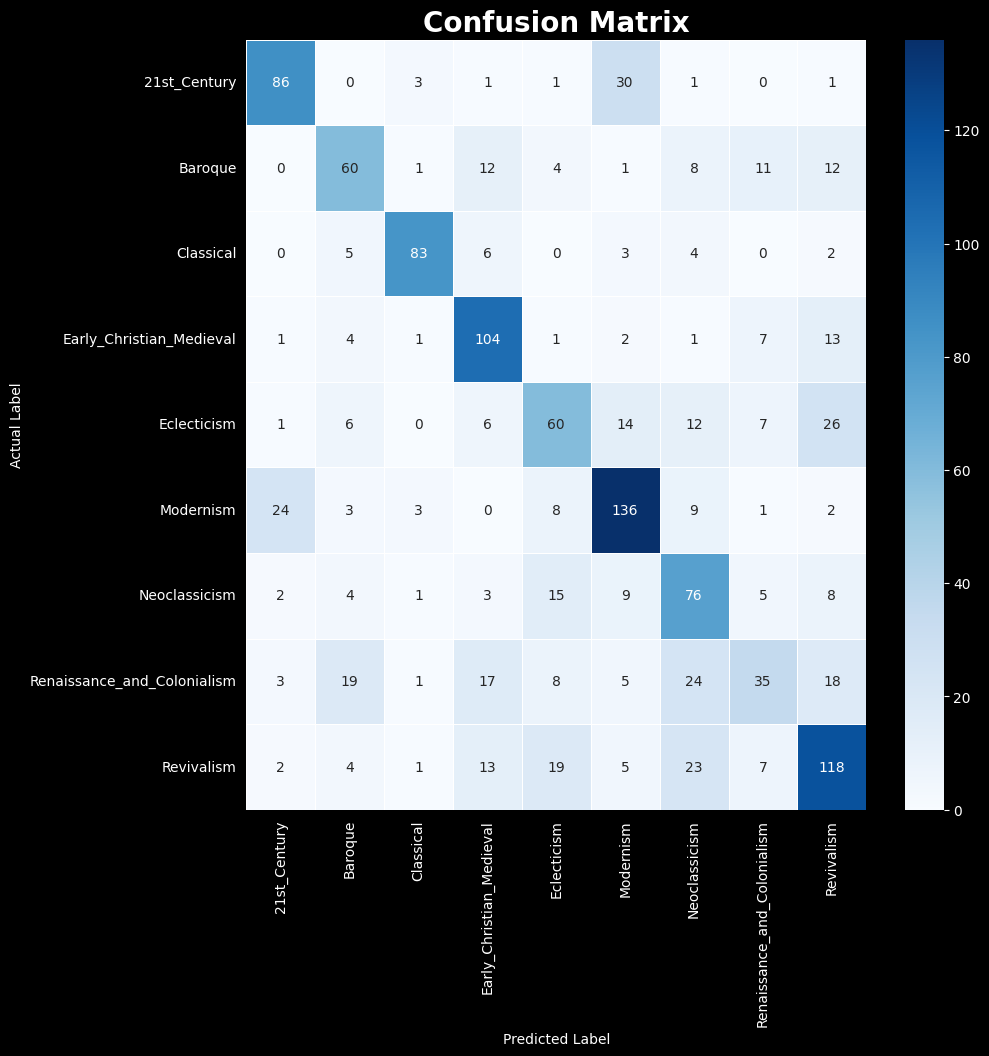

In [14]:
visualize_cm(deep_gelu, class_names, test_set)

In [15]:
torch.save(deep_gelu, 'deep_gelu.pt')

# SiLU

In [16]:
deep_silu = nn.Sequential(
    nn.Linear(512, 256),
    nn.SiLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 128),
    nn.SiLU(),
    nn.Linear(128, 9),
)

In [17]:
res_mod_silu = models.resnet18(weights='IMAGENET1K_V1')

for name, child in res_mod_silu.named_children():
     if name == 'fc':
         print(name + ' has been unfrozen.')
         for param in child.parameters():
             param.requires_grad = True
     else:
        for param in child.parameters():
            param.requires_grad = False

res_mod_silu.fc = deep_silu

res_mod_silu = res_mod_silu.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_silu = torch.optim.SGD(filter(lambda x: x.requires_grad, res_mod_silu.parameters()), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu, step_size=7, gamma=0.1)

fc has been unfrozen.


In [18]:
deep_silu_mod, metrics_silu = train_model(res_mod_silu, criterion, optimizer_silu, exp_lr_scheduler, dataloaders, dataset_sizes, 25)

val Loss: 1.1281 | Acc: 0.6238 | Weighted Acc: 0.5791 | F1-macro: 0.6232 | Top-1 Acc: 0.6238 | Top-3 Acc: 0.8958
Epoch Time: 17.7292s

Training complete in 7m 28s
Best val Weighted Acc: 0.588924 | Best F1-score: 0.6264 | Best Top-1 Acc: 0.6319 | Best Top-3 Acc: 0.9007


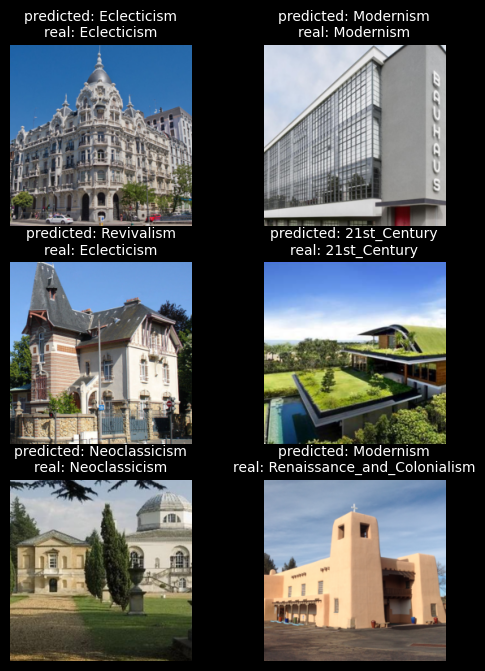

In [19]:
visualize_model(deep_silu_mod, num_images=6, class_names=class_names, vis_loader=vis_loader)

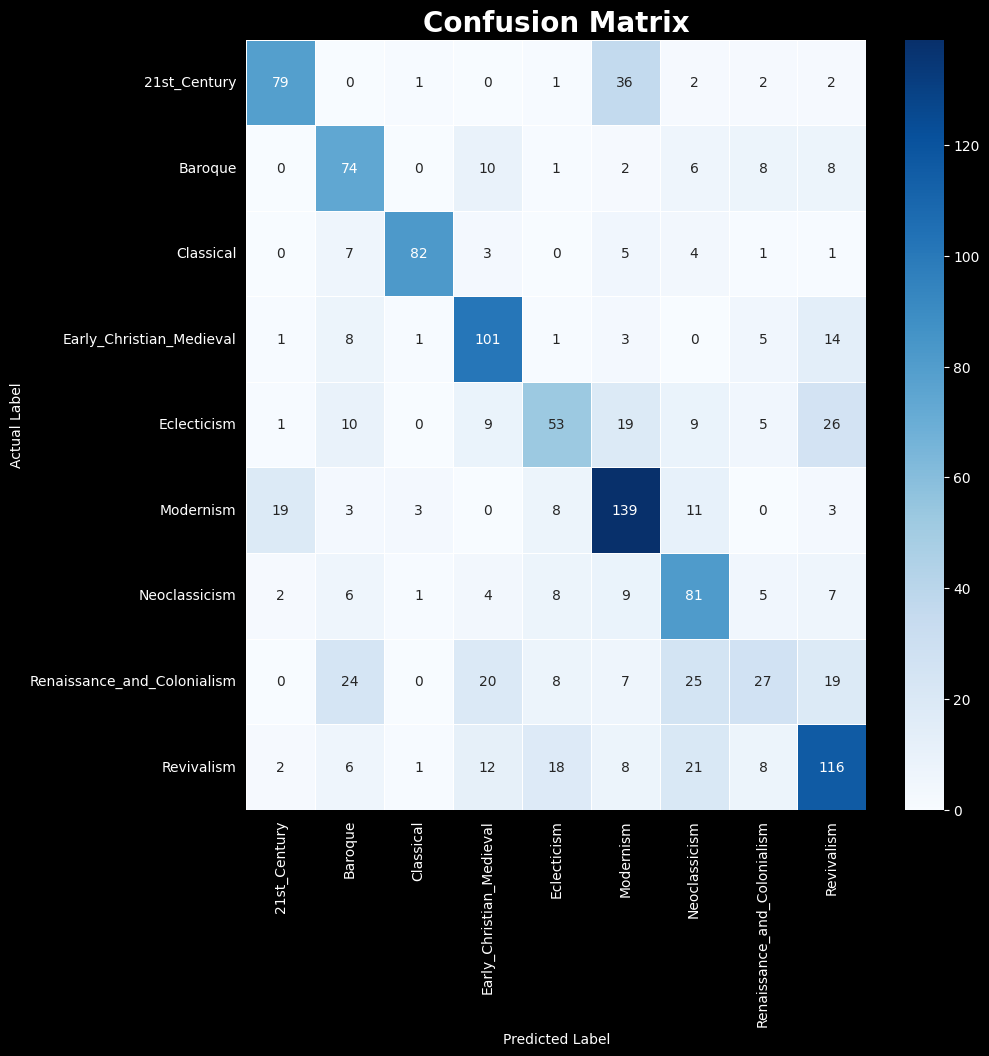

In [20]:
visualize_cm(deep_silu_mod, class_names, test_set)

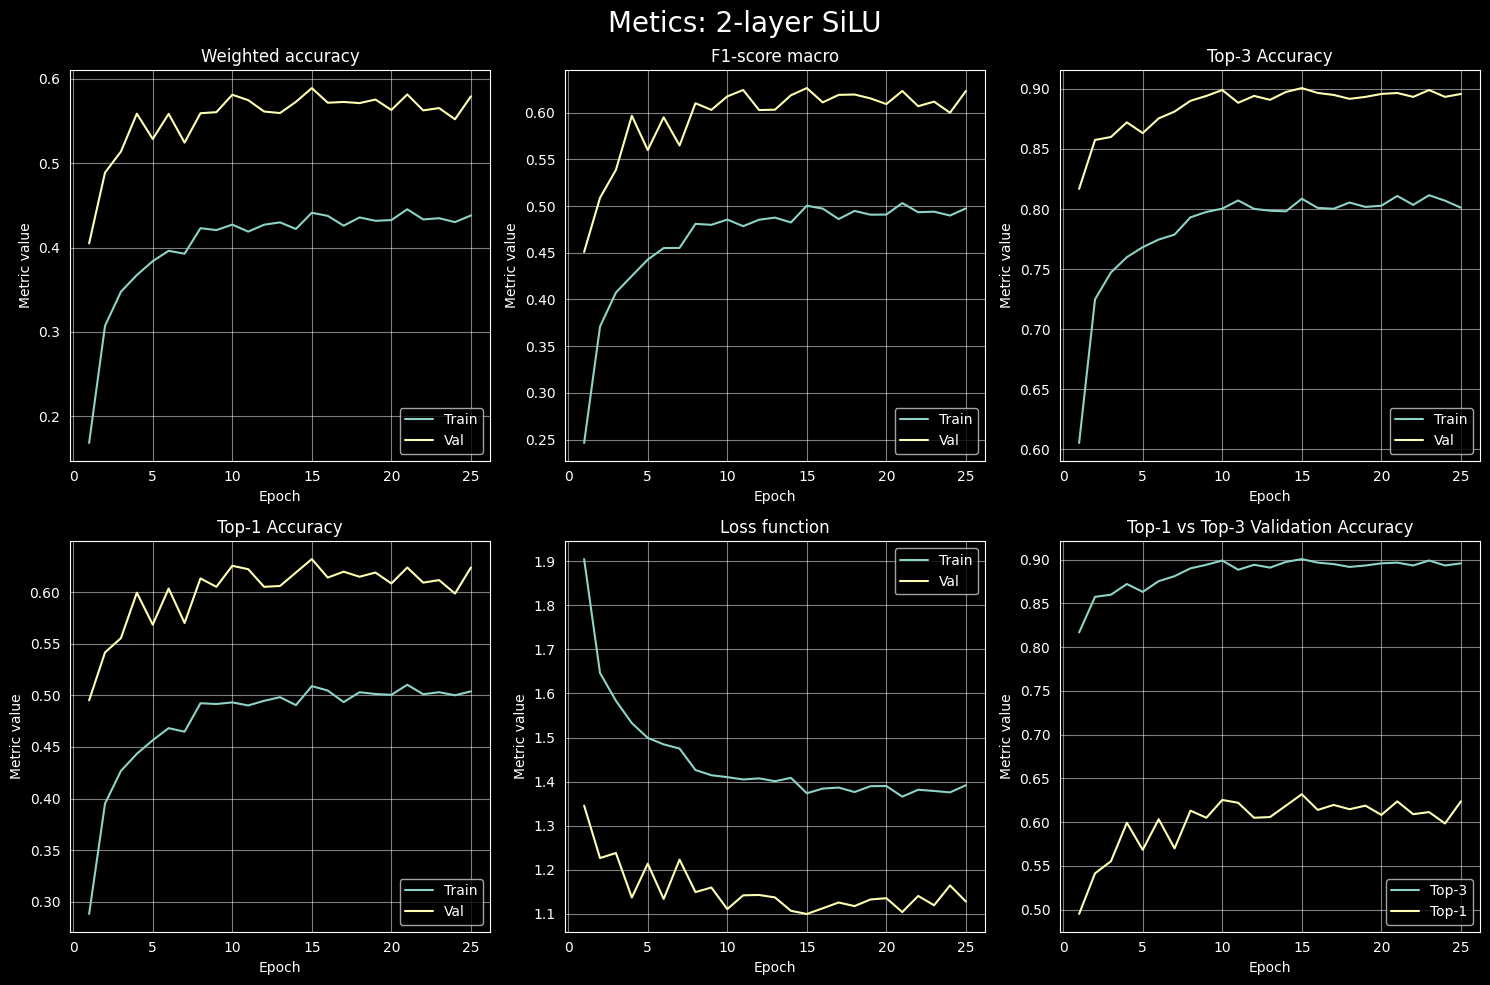

In [21]:
visualize_metrics(metrics_silu, "Metics: 2-layer SiLU", 25)

In [22]:
torch.save(deep_silu_mod, 'deep_silu.pt')

## дообучить попробуем

In [23]:
deep_silu_mod = deep_silu_mod.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_silu_strong = torch.optim.SGD(filter(lambda x: x.requires_grad, deep_silu_mod.parameters()), lr=0.0001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_silu_strong, step_size=7, gamma=0.1)

In [24]:
deep_silu_new, metrics_silu_new = train_model(deep_silu_mod, criterion, optimizer_silu_strong, exp_lr_scheduler, dataloaders, dataset_sizes, 35)

val Loss: 1.1257 | Acc: 0.6197 | Weighted Acc: 0.5730 | F1-macro: 0.6206 | Top-1 Acc: 0.6197 | Top-3 Acc: 0.8982
Epoch Time: 18.1439s

Training complete in 10m 40s
Best val Weighted Acc: 0.596077 | Best F1-score: 0.6362 | Best Top-1 Acc: 0.6401 | Best Top-3 Acc: 0.9064


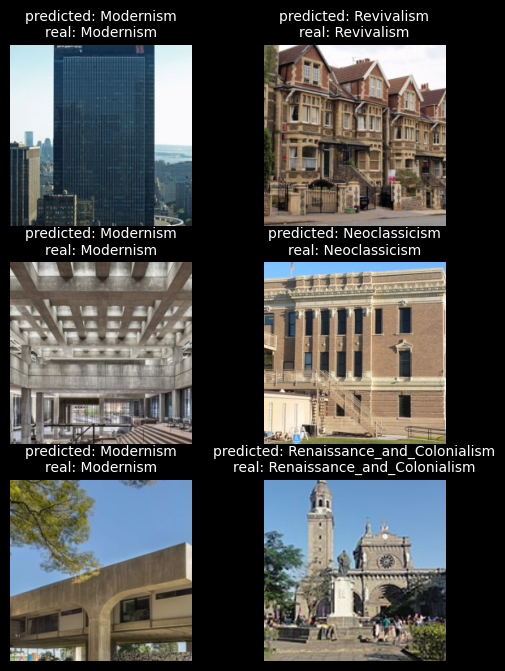

In [25]:
visualize_model(deep_silu_new, num_images=6, class_names=class_names, vis_loader=vis_loader)

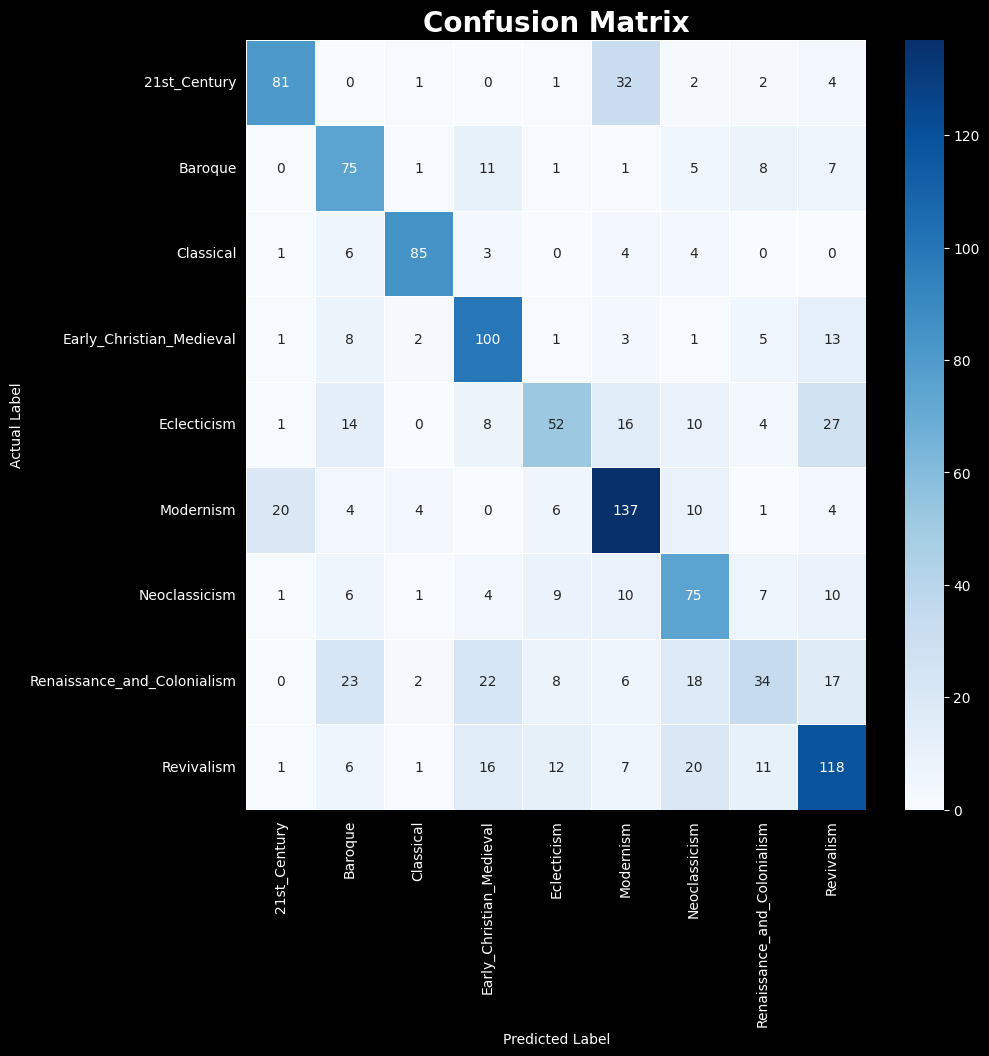

In [26]:
visualize_cm(deep_silu_new, class_names, test_set)

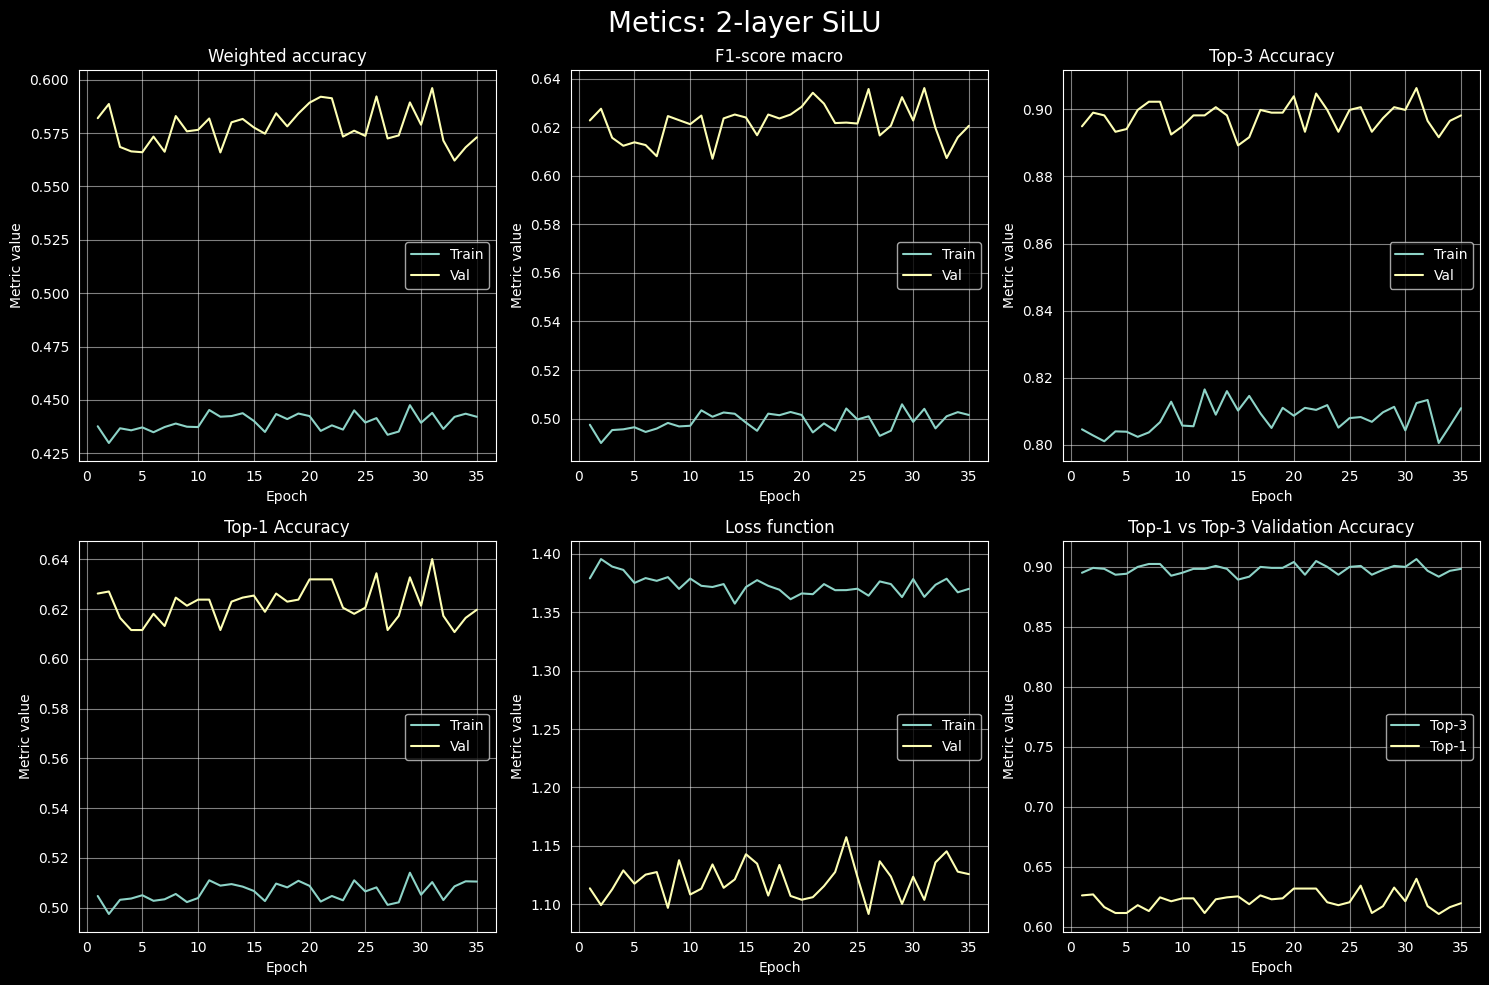

In [27]:
visualize_metrics(metrics_silu_new, "Metics: 2-layer SiLU", 35)

In [28]:
torch.save(deep_silu_new, 'deep_silu_new.pt')